# 01 — Exploratory Data Analysis

Analisi esplorativa dei dataset ALLARMI e TIPOLOGIA_VIAGGIATORE dopo il preprocessing.

**Obiettivo**: capire distribuzioni, pattern per rotta e nazionalità, e identificare
dove le anomalie tendono a concentrarsi — prima di eseguire qualsiasi modello.

**Dataset**:
- `allarmi_clean.csv` — conteggi aggregati per rotta, data e tipo occorrenza
- `viaggiatori_clean.csv` — una riga per controllo passeggero, con demografica ed esito

**Struttura**:
1. Setup & caricamento
2. TIPOLOGIA_VIAGGIATORE — distribuzioni, tassi di allarme, demografica
3. ALLARMI — volumi e breakdown per rotta
4. Tasso di allarme per nazionalità e zona
5. Flag bassa osservabilità

## 1. Setup & caricamento

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ROOT     = Path.cwd().parent if (Path.cwd().parent / 'data').exists() else Path.cwd()
PROC_DIR = ROOT / 'data' / 'processed'

v = pd.read_csv(PROC_DIR / 'viaggiatori_clean.csv', parse_dates=['DATA_PARTENZA'])
a = pd.read_csv(PROC_DIR / 'allarmi_clean.csv',     parse_dates=['DATA_PARTENZA'])

print(f'viaggiatori: {v.shape[0]:,} righe × {v.shape[1]} colonne')
print(f'allarmi:     {a.shape[0]:,} righe × {a.shape[1]} colonne')

viaggiatori: 5,095 righe × 33 colonne
allarmi:     5,080 righe × 22 colonne


## 2. TIPOLOGIA_VIAGGIATORE

### 2.1 Statistiche descrittive

In [14]:
num_cols = ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']

desc = v[num_cols].describe().T
desc['skewness'] = v[num_cols].skew()
desc['kurtosis'] = v[num_cols].kurt()
desc.round(2)

# Nota: skewness elevata su ENTRATI giustifica il log1p usato nel feature engineering

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
ENTRATI,4889.0,42.47,251.26,0.0,1.0,3.0,76.0,10000.0,38.22,1512.68
INVESTIGATI,4889.0,35.35,47.22,0.0,1.0,2.0,74.0,186.0,1.02,-0.39
ALLARMATI,4889.0,6.40,13.52,0.0,0.0,1.0,10.0,163.0,5.60,42.80


### 2.2 Distribuzioni e boxplot

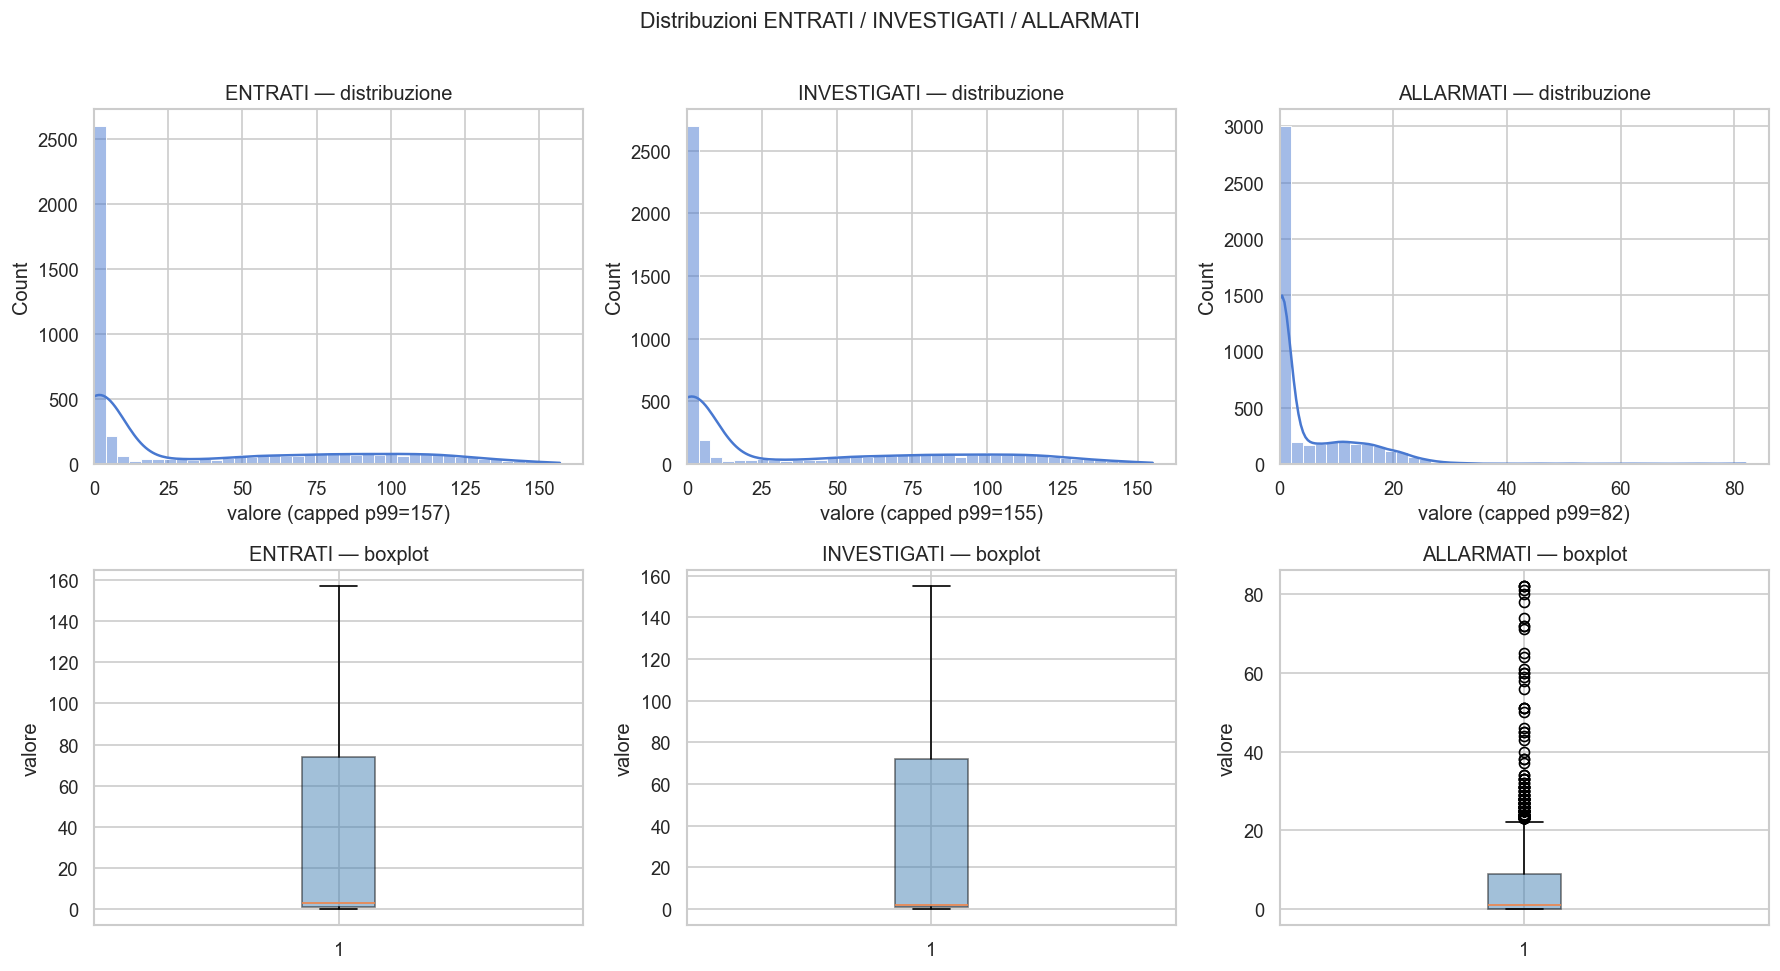

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    data      = v[col].dropna()
    cap       = data.quantile(0.99)
    data_cap  = data[data <= cap]

    sns.histplot(data_cap, bins=40, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'{col} — distribuzione')
    axes[0, i].set_xlabel(f'valore (capped p99={cap:.0f})')
    axes[0, i].set_xlim(left=0)

    axes[1, i].boxplot(data_cap, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[1, i].set_title(f'{col} — boxplot')
    axes[1, i].set_ylabel('valore')

plt.suptitle('Distribuzioni ENTRATI / INVESTIGATI / ALLARMATI', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Correlazione

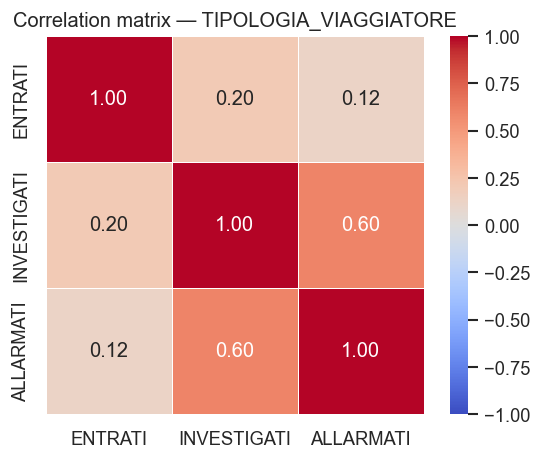

In [16]:
corr = v[num_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation matrix — TIPOLOGIA_VIAGGIATORE')
plt.tight_layout()
plt.show()

### 2.4 Tasso di allarme per genere e fascia d'età

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# alarm rate per genere
genere_stats = v.groupby('GENERE')[['ENTRATI', 'ALLARMATI']].sum()
genere_stats['alarm_rate'] = genere_stats['ALLARMATI'] / genere_stats['ENTRATI']
axes[0, 0].bar(genere_stats.index, genere_stats['alarm_rate'],
               color=sns.color_palette('muted'))
axes[0, 0].set_title('Alarm rate per genere')
axes[0, 0].set_ylabel('ALLARMATI / ENTRATI')

# distribuzione fascia età
age_order  = ['0-17', '18-30', '31-45', '46-60', '61+']
eta = v['FASCIA_ETA'].value_counts(dropna=True).reindex(age_order, fill_value=0)
axes[0, 1].bar(eta.index, eta.values, color=sns.color_palette('muted'))
axes[0, 1].set_title("Distribuzione fascia d'età")
axes[0, 1].set_ylabel('count')

# esito controllo
esito = v['ESITO_CONTROLLO'].value_counts(dropna=True)
axes[1, 0].barh(esito.index.astype(str), esito.values,
                color=sns.color_palette('muted'))
axes[1, 0].set_title('Esito controllo')
axes[1, 0].set_xlabel('count')

# alarm rate per fascia età
age_stats = v.groupby('FASCIA_ETA')[['ENTRATI', 'ALLARMATI']].sum()
age_stats = age_stats.reindex(age_order).dropna()
age_stats['alarm_rate'] = age_stats['ALLARMATI'] / age_stats['ENTRATI']
axes[1, 1].bar(age_stats.index, age_stats['alarm_rate'],
               color=sns.color_palette('muted'))
axes[1, 1].set_title("Alarm rate per fascia d'età")
axes[1, 1].set_ylabel('ALLARMATI / ENTRATI')

plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 15) (251590961.py, line 15)

### 2.5 Heatmap alarm rate: GENERE × FASCIA_ETÀ

In [ ]:
age_order = ['0-17', '18-30', '31-45', '46-60', '61+']

# Aggregazione esplicita (evita warning/deprecazioni di groupby.apply)
cross_counts = (
    v.groupby(['GENERE', 'FASCIA_ETA'])[['ALLARMATI', 'ENTRATI']]
    .sum()
    .reset_index()
)
cross_counts['alarm_rate'] = np.where(
    cross_counts['ENTRATI'] > 0,
    cross_counts['ALLARMATI'] / cross_counts['ENTRATI'],
    np.nan,
)

cross = (
    cross_counts
    .pivot(index='GENERE', columns='FASCIA_ETA', values='alarm_rate')
    .reindex(columns=age_order)
)

plt.figure(figsize=(9, 3))
sns.heatmap(cross, annot=True, fmt='.2%', cmap='YlOrRd', linewidths=0.5)
plt.title('Alarm rate: GENERE × FASCIA_ETÀ')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Interpretazione: le celle più scure indicano le combinazioni demografiche
# con il più alto tasso di allarme — input qualitativo per il report finale

### 2.6 Alarm rate per tipo documento

In [ ]:
doc_stats = v.groupby('TIPO_DOCUMENTO')[['ENTRATI', 'ALLARMATI']].sum()
doc_stats['alarm_rate'] = doc_stats['ALLARMATI'] / doc_stats['ENTRATI']
doc_stats = doc_stats.sort_values('alarm_rate', ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(doc_stats.index, doc_stats['alarm_rate'],
        color=sns.color_palette('muted'))
plt.title('Alarm rate per tipo documento')
plt.xlabel('TIPO_DOCUMENTO')
plt.ylabel('ALLARMATI / ENTRATI')
plt.tight_layout()
plt.show()

print(doc_stats[['ENTRATI', 'ALLARMATI', 'alarm_rate']].round(3).to_string())

### 2.7 Trend mensile

In [ ]:
# Usa DATA_PARTENZA per il trend — MESE_PARTENZA ha encoding misto nel raw
v['_mese'] = v['DATA_PARTENZA'].dt.month
month_stats = v.dropna(subset=['_mese']).groupby('_mese')[
    ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']
].sum()

month_labels = {1:'Gen', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mag', 6:'Giu',
                7:'Lug', 8:'Ago', 9:'Set', 10:'Ott', 11:'Nov', 12:'Dic'}
month_stats.index = month_stats.index.map(lambda x: month_labels.get(int(x), str(x)))

plt.figure(figsize=(10, 4))
for col in ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']:
    plt.plot(month_stats.index, month_stats[col], marker='o', label=col)
plt.title('Trend mensile — TIPOLOGIA_VIAGGIATORE')
plt.xlabel('mese')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

v.drop(columns=['_mese'], inplace=True)

## 3. ALLARMI

### 3.1 Top 15 rotte per volume allarmi

In [ ]:
a_rotta = a[a['OCCORRENZE'] == 'Viaggiatori con Allarmi'].copy()
a_rotta['ROTTA'] = a_rotta['AREOPORTO_PARTENZA'] + '-' + a_rotta['AREOPORTO_ARRIVO']

top_rotte = (a_rotta.groupby('ROTTA')['TOT']
             .sum()
             .sort_values(ascending=False)
             .head(15))

top_rotte.index = [f"{r.split('-')[0]} → {r.split('-')[1]}" for r in top_rotte.index]

plt.figure(figsize=(12, 5))
plt.barh(top_rotte.index[::-1], top_rotte.values[::-1],
         color=sns.color_palette('muted'))
plt.title('Top 15 rotte per volume allarmi (Viaggiatori con Allarmi)')
plt.xlabel('totale allarmi')
plt.tight_layout()
plt.show()

### 3.2 Breakdown per MOTIVO_ALLARME

In [ ]:
motivo = a['MOTIVO_ALLARME'].value_counts(dropna=True)

plt.figure(figsize=(8, 4))
plt.bar(motivo.index, motivo.values, color=sns.color_palette('muted'))
plt.title('Sorgente allarmi (MOTIVO_ALLARME)')
plt.xlabel('motivo')
plt.ylabel('count')
plt.tight_layout()
plt.show()

motivo_pct = (motivo / motivo.sum() * 100).round(1)
print('Distribuzione percentuale:')
print(motivo_pct.to_string())

## 4. Tasso di allarme per nazionalità e zona

### 4.1 Alarm rate per nazionalità (min 30 viaggiatori)

In [ ]:
# Soglia minima 30 per affidabilità statistica.
# Nazionalità con meno osservazioni vengono flaggate separatamente (sezione 5).
# Filtriamo anche i codici che sono ancora valori NULL non risolti.
NULL_CODES = {'ND', 'XX', '???', 'UNK', 'UNKN', 'EU', 'ZZ'}

nat_stats = v.groupby('NAZIONALITA').agg(
    entrati   = ('ENTRATI',   'sum'),
    allarmati = ('ALLARMATI', 'sum')
).dropna()

nat_stats = nat_stats[
    (nat_stats['entrati'] >= 30) &
    (~nat_stats.index.isin(NULL_CODES))
].copy()

nat_stats['alarm_rate'] = nat_stats['allarmati'] / nat_stats['entrati']
nat_stats = nat_stats.sort_values('alarm_rate', ascending=False).head(20)

plt.figure(figsize=(13, 5))
plt.bar(nat_stats.index, nat_stats['alarm_rate'],
        color=sns.color_palette('muted'))
plt.title('Alarm rate per nazionalità (min 30 viaggiatori, top 20)')
plt.xlabel('NAZIONALITA')
plt.ylabel('ALLARMATI / ENTRATI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(nat_stats[['entrati', 'allarmati', 'alarm_rate']].round(3).to_string())

### 4.2 Alarm rate per zona geografica

In [ ]:
# Zone valide nel dataset: [1,2,4,5,6,7,8,9]
# Zona 3 non è presente nel dataset (confermato in EDA).
valid_zones = [1, 2, 4, 5, 6, 7, 8, 9]

zona_df = (v[v['ZONA'].isin(valid_zones)]
           .groupby('ZONA')[['ENTRATI', 'ALLARMATI']]
           .sum())
zona_df['alarm_rate'] = zona_df['ALLARMATI'] / zona_df['ENTRATI']
zona_df = zona_df.sort_values('alarm_rate', ascending=False)
zona_df.index = zona_df.index.astype(int).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(zona_df.index, zona_df['alarm_rate'],
            color=sns.color_palette('muted'))
axes[0].set_title('Alarm rate per zona geografica')
axes[0].set_xlabel('ZONA')
axes[0].set_ylabel('ALLARMATI / ENTRATI')

axes[1].bar(zona_df.index, zona_df['ENTRATI'],
            color=sns.color_palette('muted'))
axes[1].set_title('Volume viaggiatori per zona')
axes[1].set_xlabel('ZONA')
axes[1].set_ylabel('ENTRATI')

plt.tight_layout()
plt.show()

print(zona_df[['ENTRATI', 'ALLARMATI', 'alarm_rate']].round(3).to_string())

## 5. Flag bassa osservabilità

Le rotte con meno di 30 osservazioni viaggiatori non vengono escluse dall'anomaly detection,
ma vengono **flaggate separatamente**. Un alto tasso di allarme su pochi viaggiatori potrebbe
essere lei stessa l'anomalia — escluderla significherebbe perdere il caso interessante.

Queste rotte verranno trattate come cluster separato nel report finale.

In [ ]:
features = pd.read_csv(PROC_DIR / 'features_classical.csv')

soglia = 30
features['flag_bassa_osservabilita'] = features['n_osservazioni_viag'] < soglia

n_bassa = features['flag_bassa_osservabilita'].sum()
n_tot   = len(features)

print(f'Rotte con < {soglia} osservazioni viaggiatori: {n_bassa}/{n_tot} ({n_bassa/n_tot*100:.1f}%)')
print(f'Rotte con >= {soglia} osservazioni:            {n_tot - n_bassa}/{n_tot}')
print()

# Distribuzione score_composito nei due gruppi
bassa = features[features['flag_bassa_osservabilita']]['score_composito']
alta  = features[~features['flag_bassa_osservabilita']]['score_composito']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(alta,  bins=30, alpha=0.7, label=f'>= {soglia} oss.', color='steelblue')
axes[0].hist(bassa, bins=30, alpha=0.7, label=f'<  {soglia} oss.', color='salmon')
axes[0].set_title('Distribuzione score_composito per osservabilità')
axes[0].set_xlabel('score_composito')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].boxplot([alta.dropna(), bassa.dropna()],
                labels=[f'>= {soglia}', f'< {soglia}'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Score composito: alta vs bassa osservabilità')
axes[1].set_ylabel('score_composito')

plt.tight_layout()
plt.show()

print('\nStatistiche score_composito:')
print(pd.DataFrame({'alta_oss': alta.describe(), 'bassa_oss': bassa.describe()}).round(4).to_string())